## **QUESTION 2 - Clustering**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering and evaluation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

# Statistical tests
from scipy.stats import entropy   # For KL Divergence
from scipy.spatial.distance import euclidean

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

In [2]:
# Read with European formatting: semicolon separator, comma as decimal
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# First look at the raw data
print("=" * 60)
print("RAW DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape} (rows x columns)")
print(f"\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

print(f"\nFirst 5 rows:")
df.head()

RAW DATASET OVERVIEW
Shape: (9471, 17) (rows x columns)

Column names:
  1. Date
  2. Time
  3. CO(GT)
  4. PT08.S1(CO)
  5. NMHC(GT)
  6. C6H6(GT)
  7. PT08.S2(NMHC)
  8. NOx(GT)
  9. PT08.S3(NOx)
  10. NO2(GT)
  11. PT08.S4(NO2)
  12. PT08.S5(O3)
  13. T
  14. RH
  15. AH
  16. Unnamed: 15
  17. Unnamed: 16

First 5 rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


Data is in European formatting: semicolon separator, comma as decimal

10/03/2004;18.00.00;2,6;1360;150;11,9;1046;166;1056;113;1692;1268;13,6;48,9;07578;;

In [3]:
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

In [4]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
df.shape

(9471, 17)

In [6]:
print(df.isnull().sum())

Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


In [7]:
print((df == -200).sum())

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Unnamed: 15         0
Unnamed: 16         0
dtype: int64


Initial Data Cleaning
1. Drop the two empty columns at the end (they contain all NaN)
2. Drop rows where ALL values are NaN (empty rows at end of file) - there are 114 rows
3. Create a proper DateTime column by combining Date and Time Date format is DD/MM/YYYY, Time format is HH.MM.SS
4. Set DateTime as the index (makes time-based analysis easier)

In [8]:
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

In [9]:
df = df.dropna(how='all')

In [10]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')

In [11]:
df = df.set_index('DateTime')
df = df.drop(columns=['Date', 'Time'])

In [12]:
df.shape

(9357, 13)

In [13]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


5. Handling missing values (-200)

Too many missing values to reliably impute (cell 13)
- Drop NMHC(GT) - 90% missing is too much to impute

In [14]:
df = df.replace(-200, np.nan)

In [15]:
df = df.drop(columns=['NMHC(GT)'])

In [16]:
print((df == -200).sum())

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [17]:
print(df.isnull().sum())

CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [18]:
print(df.isna().sum())

CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


For remaining columns above mentioned, fill missing values with the median

Impute with forward fill first (use previous hour's value), then median for any remaining

In [19]:
df = df.fillna(method='ffill')
df = df.fillna(df.median())

In [20]:
print(df.isna().sum())

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [21]:
print(f"Final shape: {df.shape}")

Final shape: (9357, 12)


**2.1 EDA**

1. Statustical Summary
- Added Range and IQR to identify possible outliers

In [22]:
desc = df.describe().T
desc['range'] = desc['max'] - desc['min']
desc['IQR'] = desc['75%'] - desc['25%']

print(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'IQR']].to_string())

                count         mean         std       min        25%        50%        75%       max      range       IQR
CO(GT)         9357.0     2.082195    1.469801    0.1000     1.0000     1.7000     2.8000    11.900    11.8000    1.8000
PT08.S1(CO)    9357.0  1102.730362  219.588101  647.0000   938.0000  1062.0000  1237.0000  2040.000  1393.0000  299.0000
C6H6(GT)       9357.0    10.190392    7.565771    0.1000     4.4000     8.3000    14.0000    63.700    63.6000    9.6000
PT08.S2(NMHC)  9357.0   942.548253  269.581368  383.0000   733.0000   911.0000  1117.0000  2214.000  1831.0000  384.0000
NOx(GT)        9357.0   240.731217  206.618453    2.0000    97.0000   174.0000   318.0000  1479.000  1477.0000  221.0000
PT08.S3(NOx)   9357.0   832.742225  255.709423  322.0000   655.0000   807.0000   968.0000  2683.000  2361.0000  313.0000
NO2(GT)        9357.0   109.414877   47.221662    2.0000    73.0000   102.0000   137.0000   340.000   338.0000   64.0000
PT08.S4(NO2)   9357.0  1453.0145

2. Distribution Plots

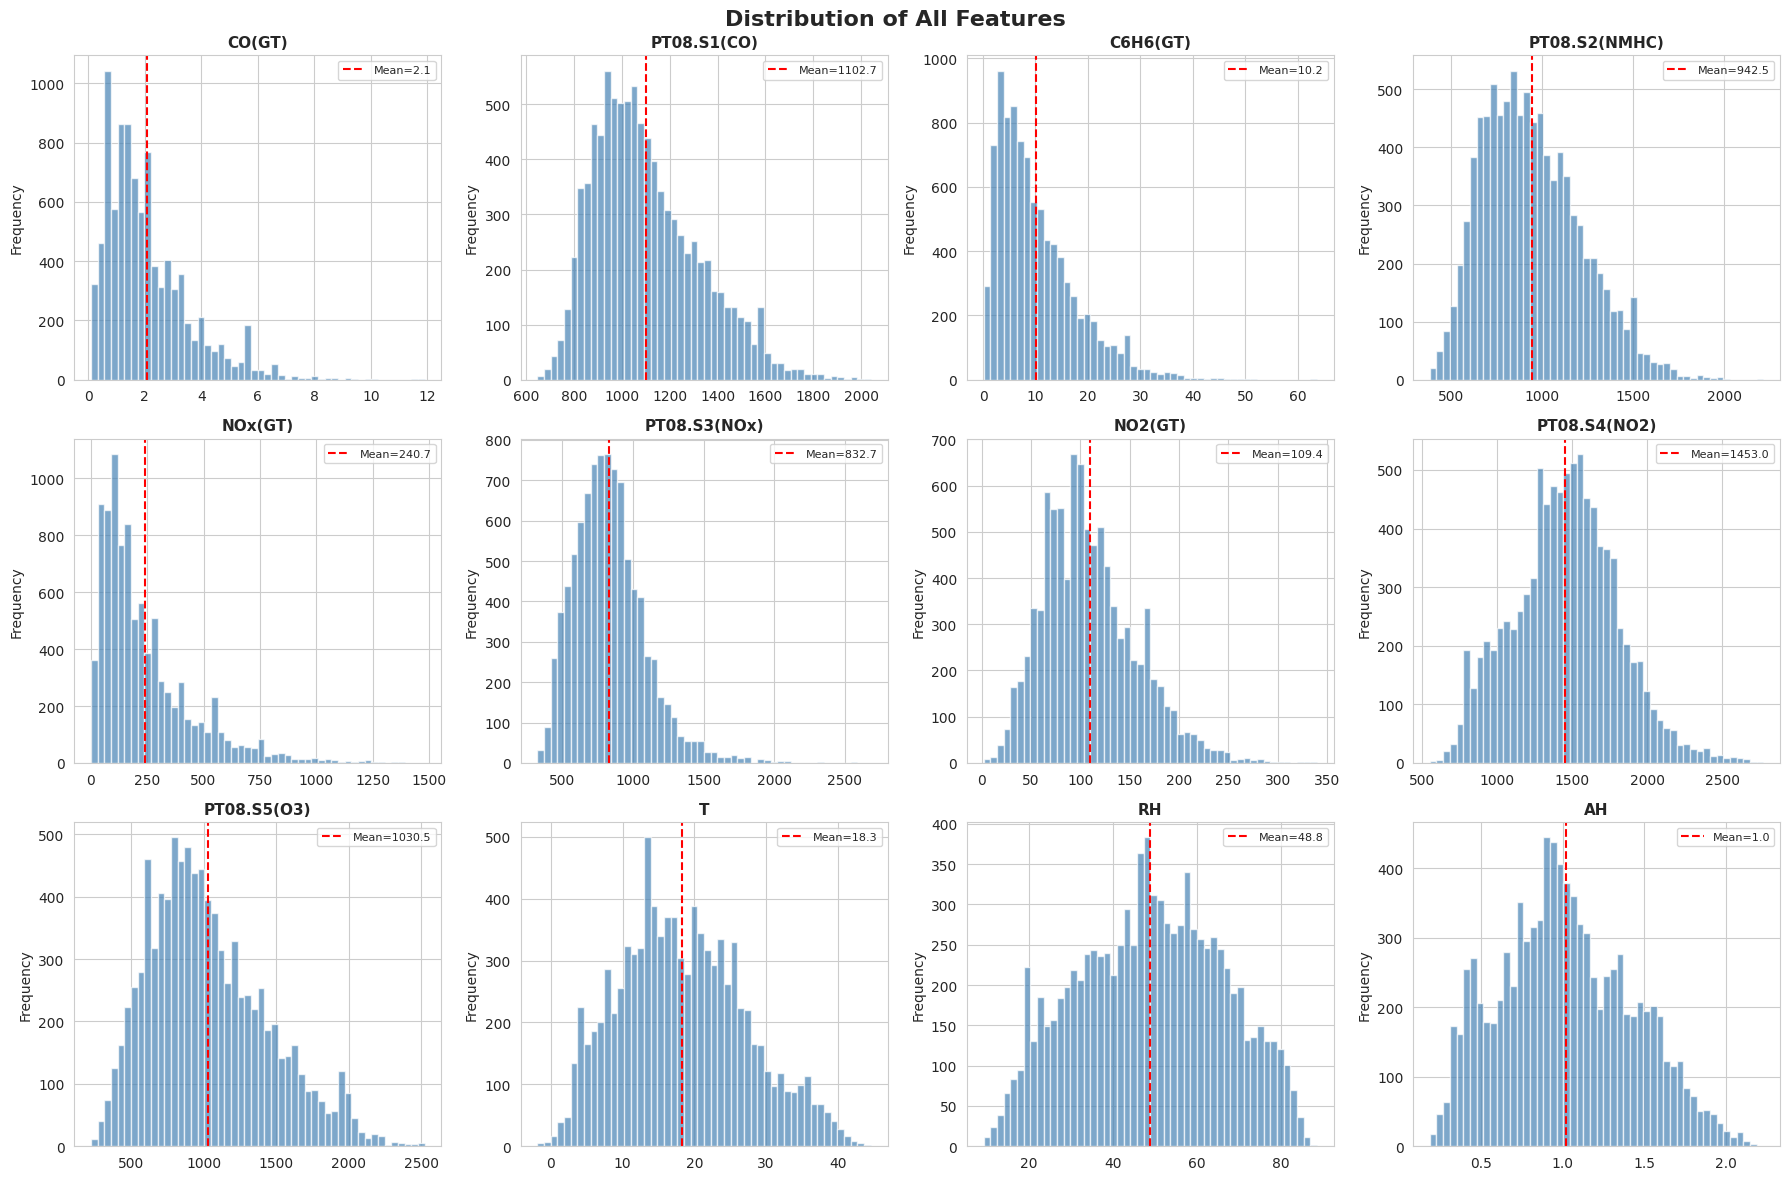

In [23]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    # Add mean line
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].legend(fontsize=8)

# Hide empty subplot if any
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Most pollution readings are low, with a few very high values.
Sensor variables look more regularly distributed.
Weather-related variables seem to change with season and environmental conditions.

 Histograms show how values are distributed for each feature.
 - Normal (bell-shaped): most values near the mean
 - Skewed: values concentrated on one side
 - Bimodal (two peaks): might indicate two distinct patterns

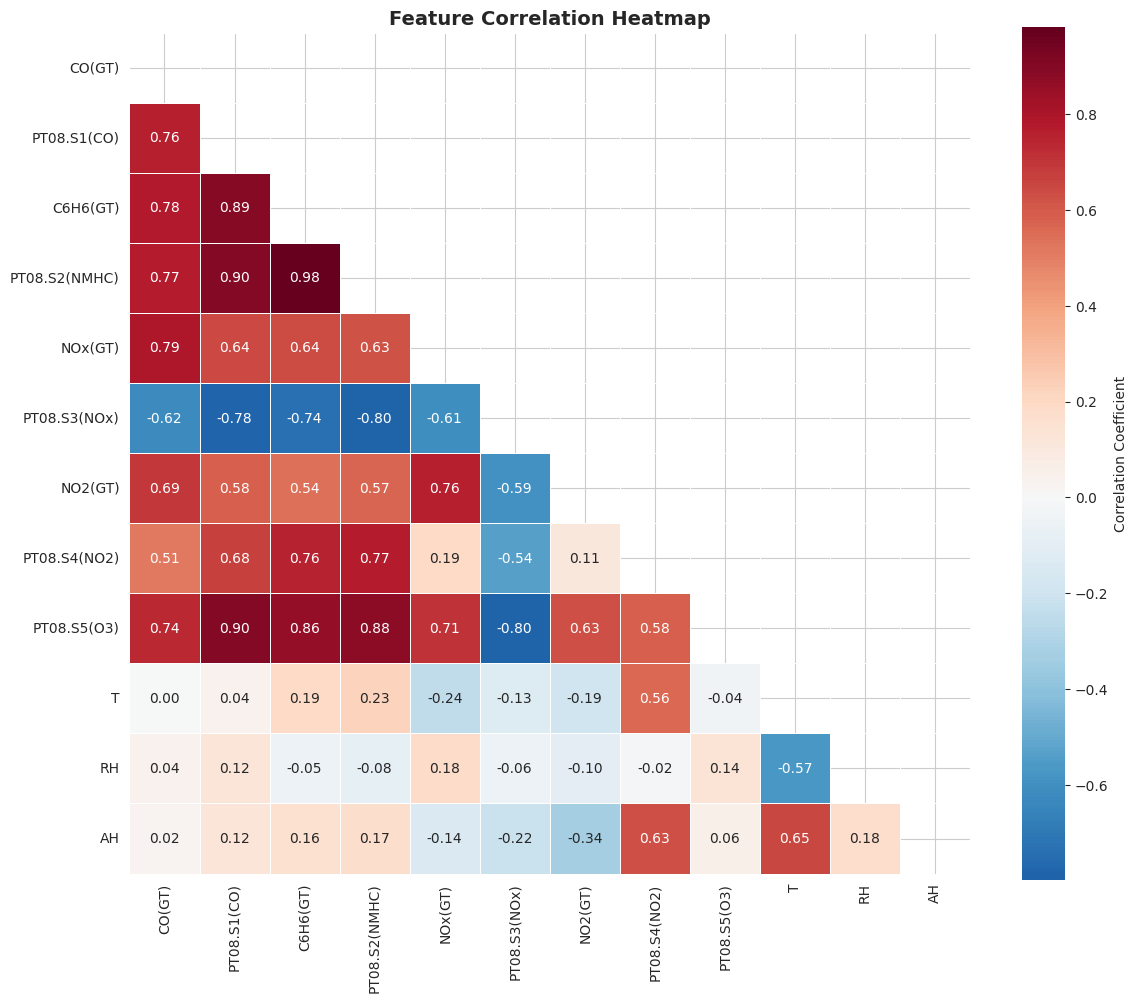


Highly Correlated Feature Pairs (|correlation| > 0.7):
  CO(GT) <-> PT08.S1(CO): 0.763
  CO(GT) <-> C6H6(GT): 0.779
  CO(GT) <-> PT08.S2(NMHC): 0.769
  CO(GT) <-> NOx(GT): 0.788
  CO(GT) <-> PT08.S5(O3): 0.737
  PT08.S1(CO) <-> C6H6(GT): 0.886
  PT08.S1(CO) <-> PT08.S2(NMHC): 0.896
  PT08.S1(CO) <-> PT08.S3(NOx): -0.778
  PT08.S1(CO) <-> PT08.S5(O3): 0.901
  C6H6(GT) <-> PT08.S2(NMHC): 0.982
  C6H6(GT) <-> PT08.S3(NOx): -0.738
  C6H6(GT) <-> PT08.S4(NO2): 0.756
  C6H6(GT) <-> PT08.S5(O3): 0.862
  PT08.S2(NMHC) <-> PT08.S3(NOx): -0.798
  PT08.S2(NMHC) <-> PT08.S4(NO2): 0.770
  PT08.S2(NMHC) <-> PT08.S5(O3): 0.877
  NOx(GT) <-> NO2(GT): 0.764
  NOx(GT) <-> PT08.S5(O3): 0.709
  PT08.S3(NOx) <-> PT08.S5(O3): -0.796


In [24]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated pairs
print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

Correlation measures how two variables move together:
- +1: Perfect positive correlation (when X goes up, Y goes up)
-  0: No correlation (X and Y are independent)
- -1: Perfect negative correlation (when X goes up, Y goes down)


Helps to understand which pollutants are related.

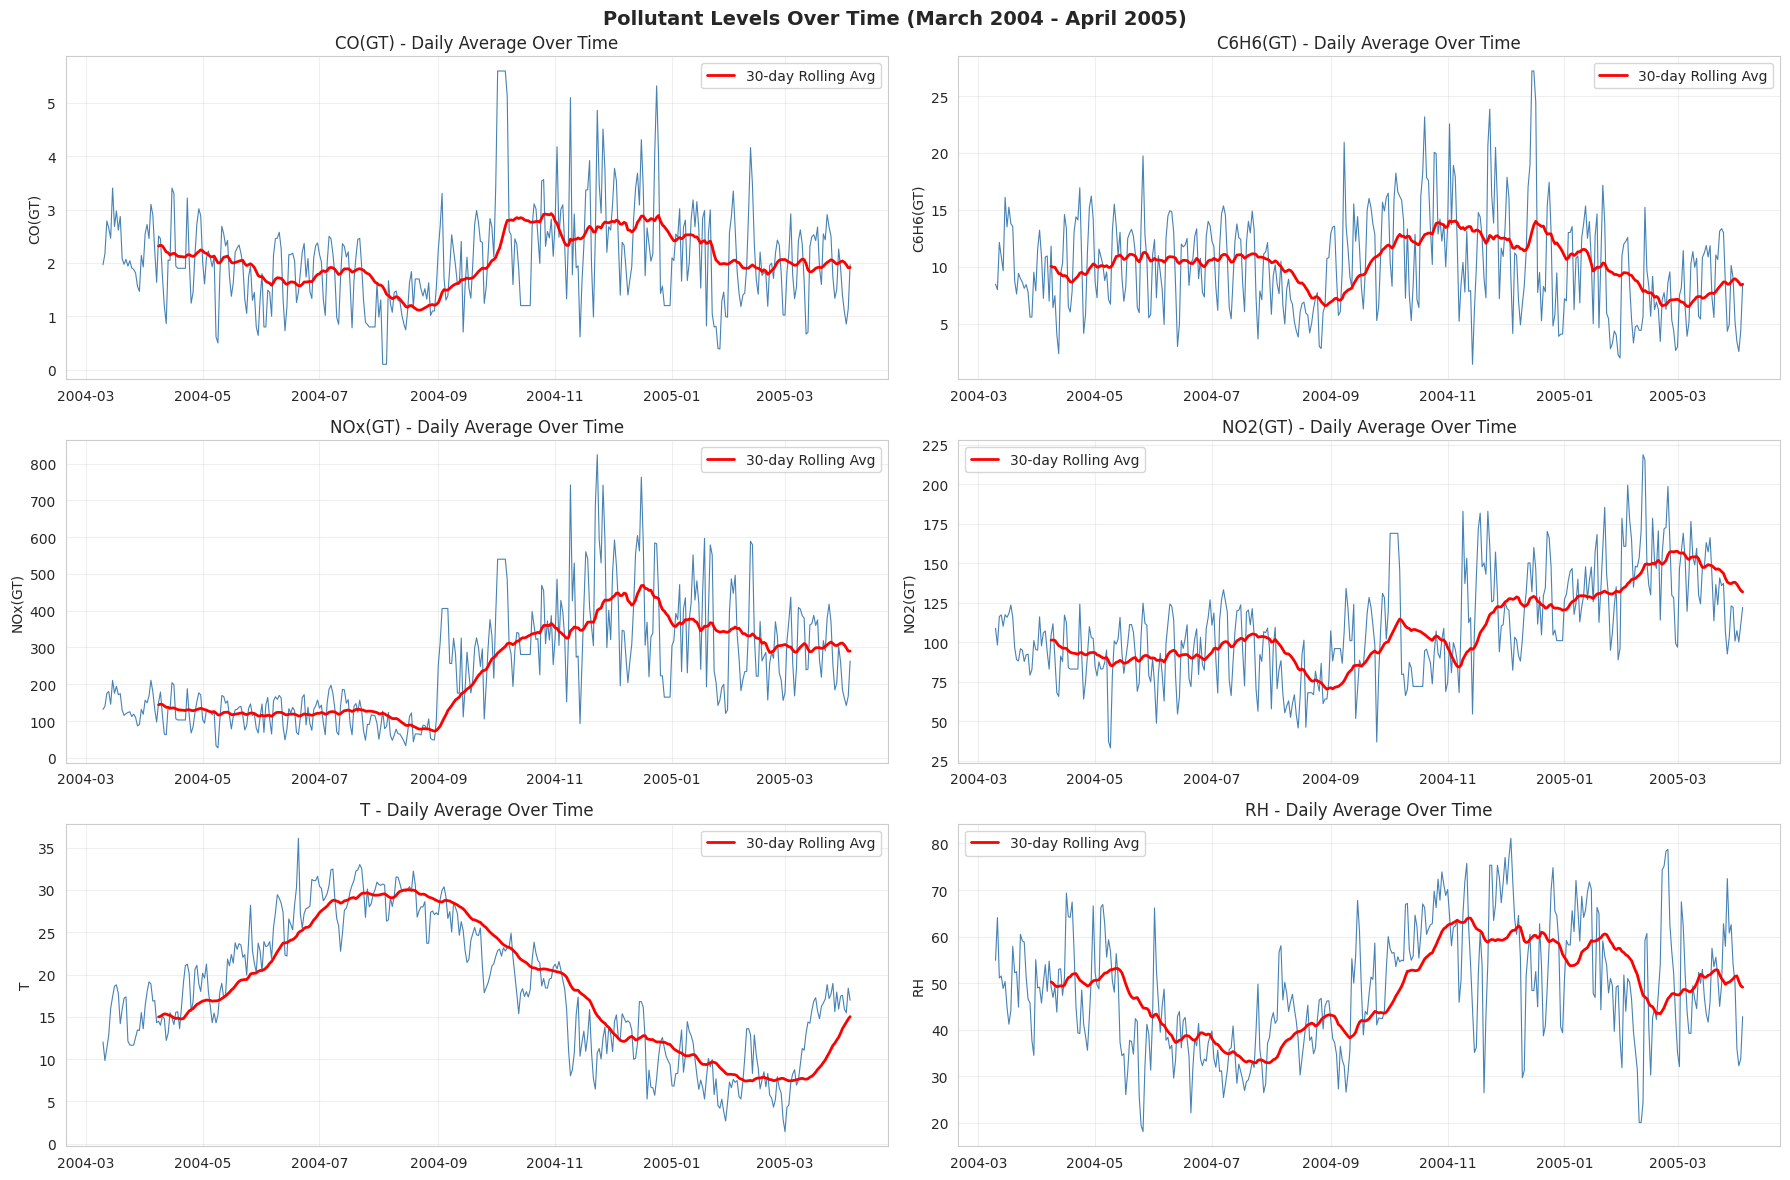

In [25]:
key_cols = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    # Resample to daily average for cleaner plot
    daily = df[col].resample('D').mean()
    axes[i].plot(daily.index, daily.values, color='steelblue', linewidth=0.8)
    axes[i].set_title(f'{col} - Daily Average Over Time', fontsize=12)
    axes[i].set_ylabel(col)
    # Add a trend line (30-day rolling average)
    rolling = daily.rolling(window=30).mean()
    axes[i].plot(rolling.index, rolling.values, color='red', linewidth=2,
                label='30-day Rolling Avg')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Pollutant Levels Over Time (March 2004 - April 2005)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('time_series.png', dpi=150, bbox_inches='tight')
plt.show()


- CO levels seem lower around late summer, then higher in the later months.
- benzene seems to follow a seasonal pattern too, with higher levels in later months.
- NOx behavior in the second period is clearly different from the first period.
- NO2 also appears higher in the later period, similar to NOx.
- temperature rises from spring into summer peaks around mid-year then falls toward winter later starts increasing again
humidity also has a seasonal pattern.
- March–August 2004 and September 2004–March 2005 may contain different air-quality regimes.

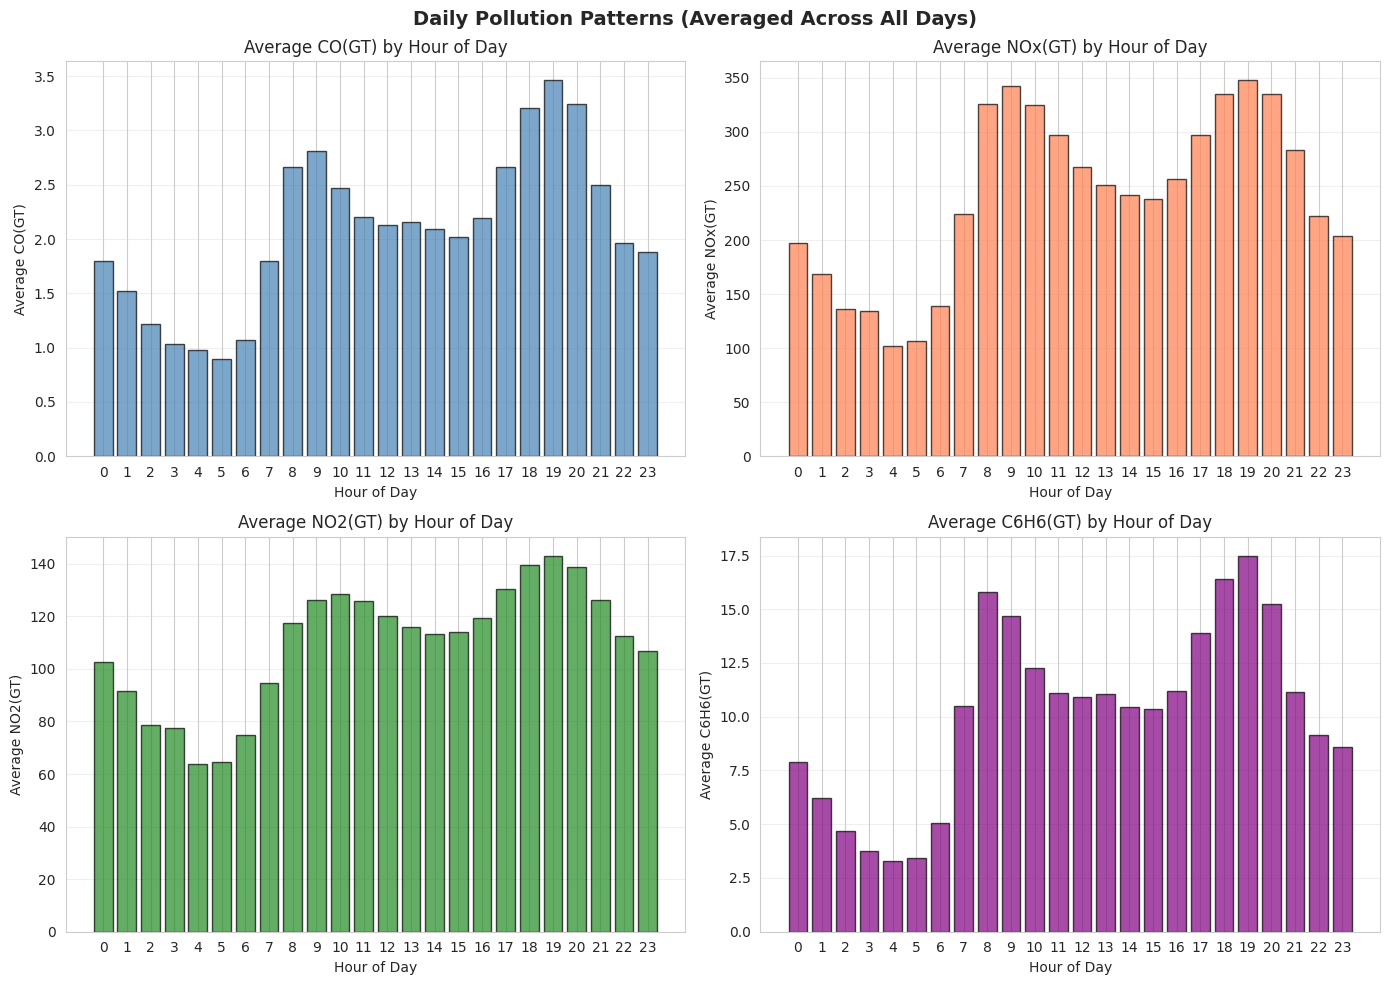

In [26]:
df['hour'] = df.index.hour

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color in zip(axes.flatten(),
                           ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)'],
                           ['steelblue', 'coral', 'forestgreen', 'purple']):
    hourly_avg = df.groupby('hour')[col].mean()
    ax.bar(hourly_avg.index, hourly_avg.values, color=color, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(f'Average {col}')
    ax.set_title(f'Average {col} by Hour of Day', fontsize=12)
    ax.set_xticks(range(0, 24))
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Daily Pollution Patterns (Averaged Across All Days)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Remove temp column
df = df.drop(columns=['hour'])

- CO seems to have two main higher periods: morning and evening.
- NOx shows a very clear daily traffic-like pattern.
- NO2 also follows a daily cycle, with higher values during active daytime and evening hours.
- Lowest pollution at 3-5 AM (least traffic)
- his confirms the data captures real urban pollution patterns

The hourly averages suggest traffic-related daily pollution cycles, with lower pollutant levels during early morning hours and higher levels during morning and evening periods.




**2.2 Outlier Detection and Removal**

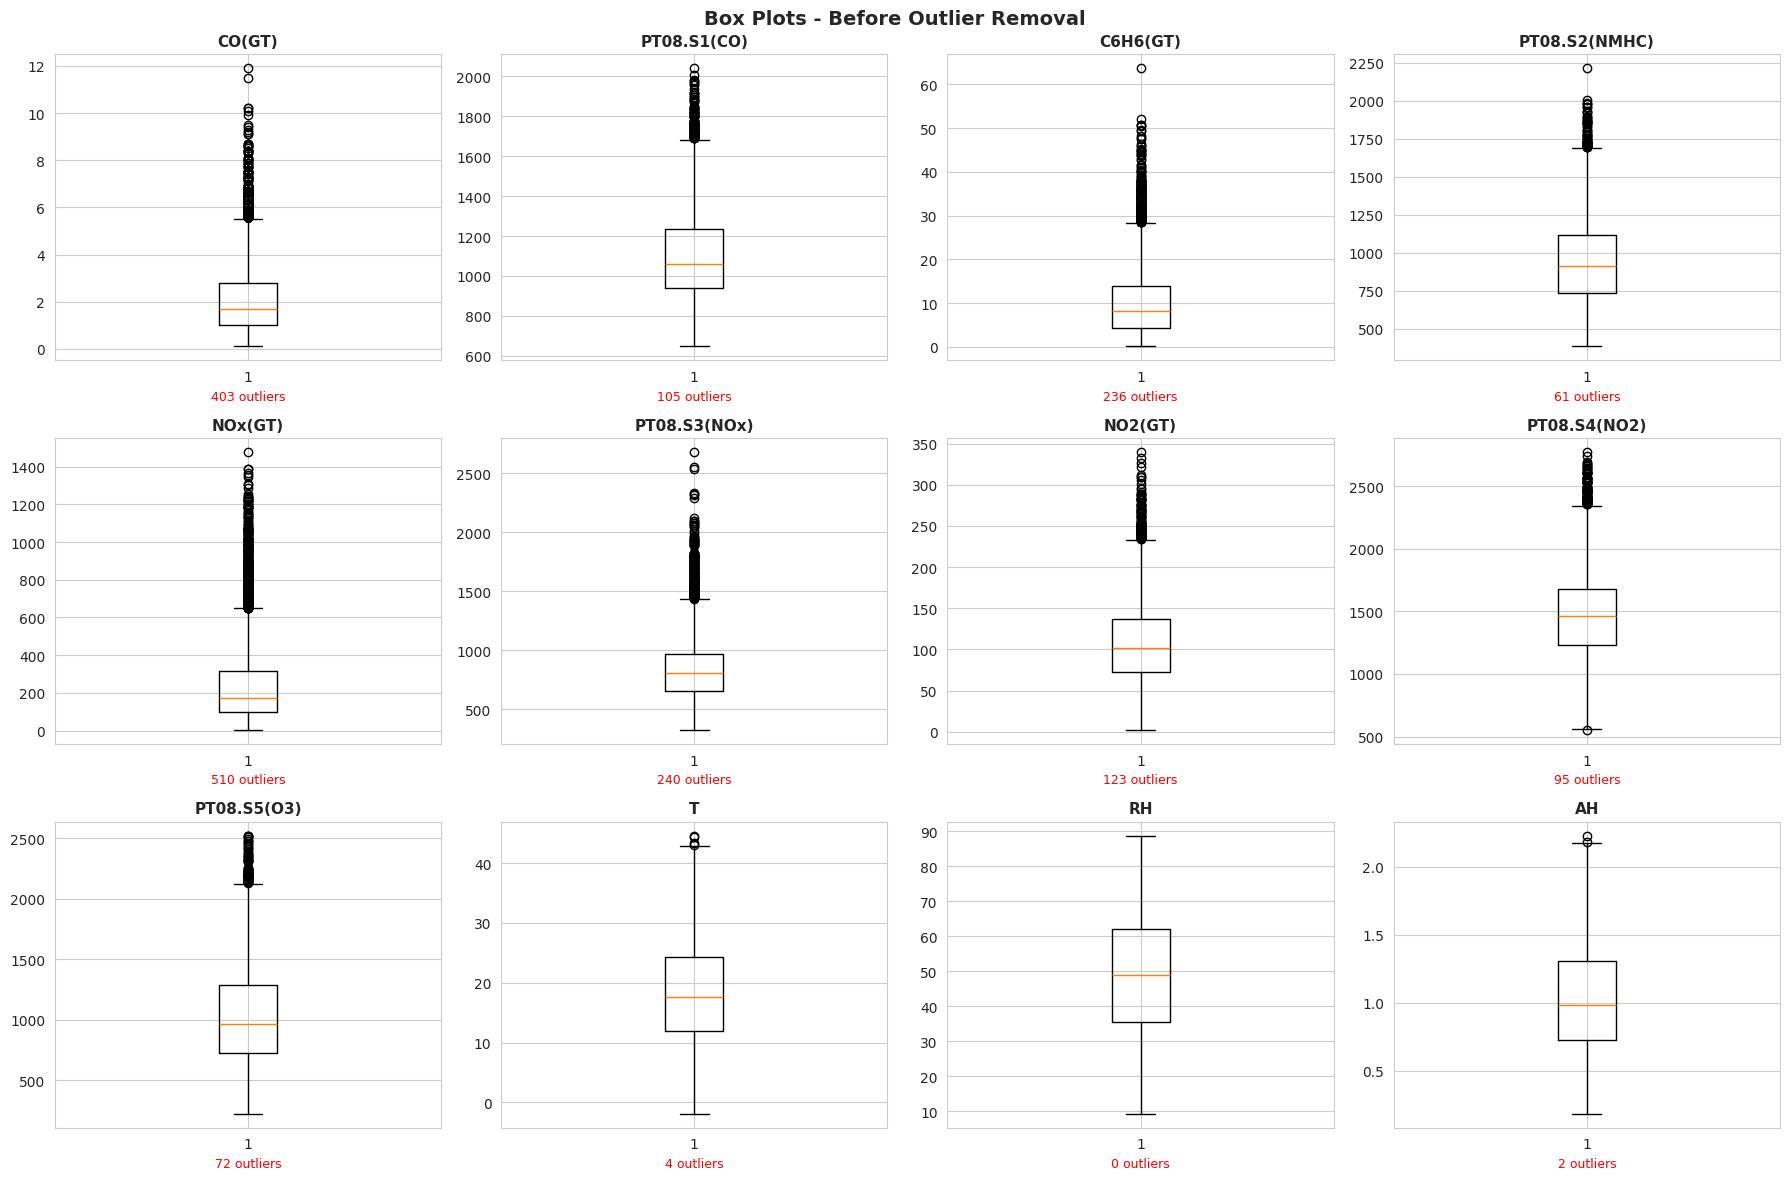

In [27]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    # Count outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'{n_outliers} outliers', fontsize=9, color='red')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots - Before Outlier Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_before.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
df_clean = df.copy()
total_outliers_capped = 0

for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    n_outliers = outliers.sum()

    if n_outliers > 0:
        print(f"  {col:>20s}: {n_outliers:>4d} outliers | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        # Cap outliers at the bounds (winsorization) instead of removing rows
        # WHY? Removing rows would lose too much data. Capping preserves the data point
        # but limits extreme values.
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
        total_outliers_capped += n_outliers

print(f"\nTotal outlier values(cells) capped: {total_outliers_capped}")
print(f"Rows retained: {len(df_clean)} (no rows dropped, outliers were capped)")

                CO(GT):  403 outliers | Bounds: [-1.70, 5.50]
           PT08.S1(CO):  105 outliers | Bounds: [489.50, 1685.50]
              C6H6(GT):  236 outliers | Bounds: [-10.00, 28.40]
         PT08.S2(NMHC):   61 outliers | Bounds: [157.00, 1693.00]
               NOx(GT):  510 outliers | Bounds: [-234.50, 649.50]
          PT08.S3(NOx):  240 outliers | Bounds: [185.50, 1437.50]
               NO2(GT):  123 outliers | Bounds: [-23.00, 233.00]
          PT08.S4(NO2):   95 outliers | Bounds: [554.50, 2350.50]
           PT08.S5(O3):   72 outliers | Bounds: [-115.50, 2128.50]
                     T:    4 outliers | Bounds: [-6.70, 42.90]
                    AH:    2 outliers | Bounds: [-0.14, 2.18]

Total outlier values(cells) capped: 1851
Rows retained: 9357 (no rows dropped, outliers were capped)


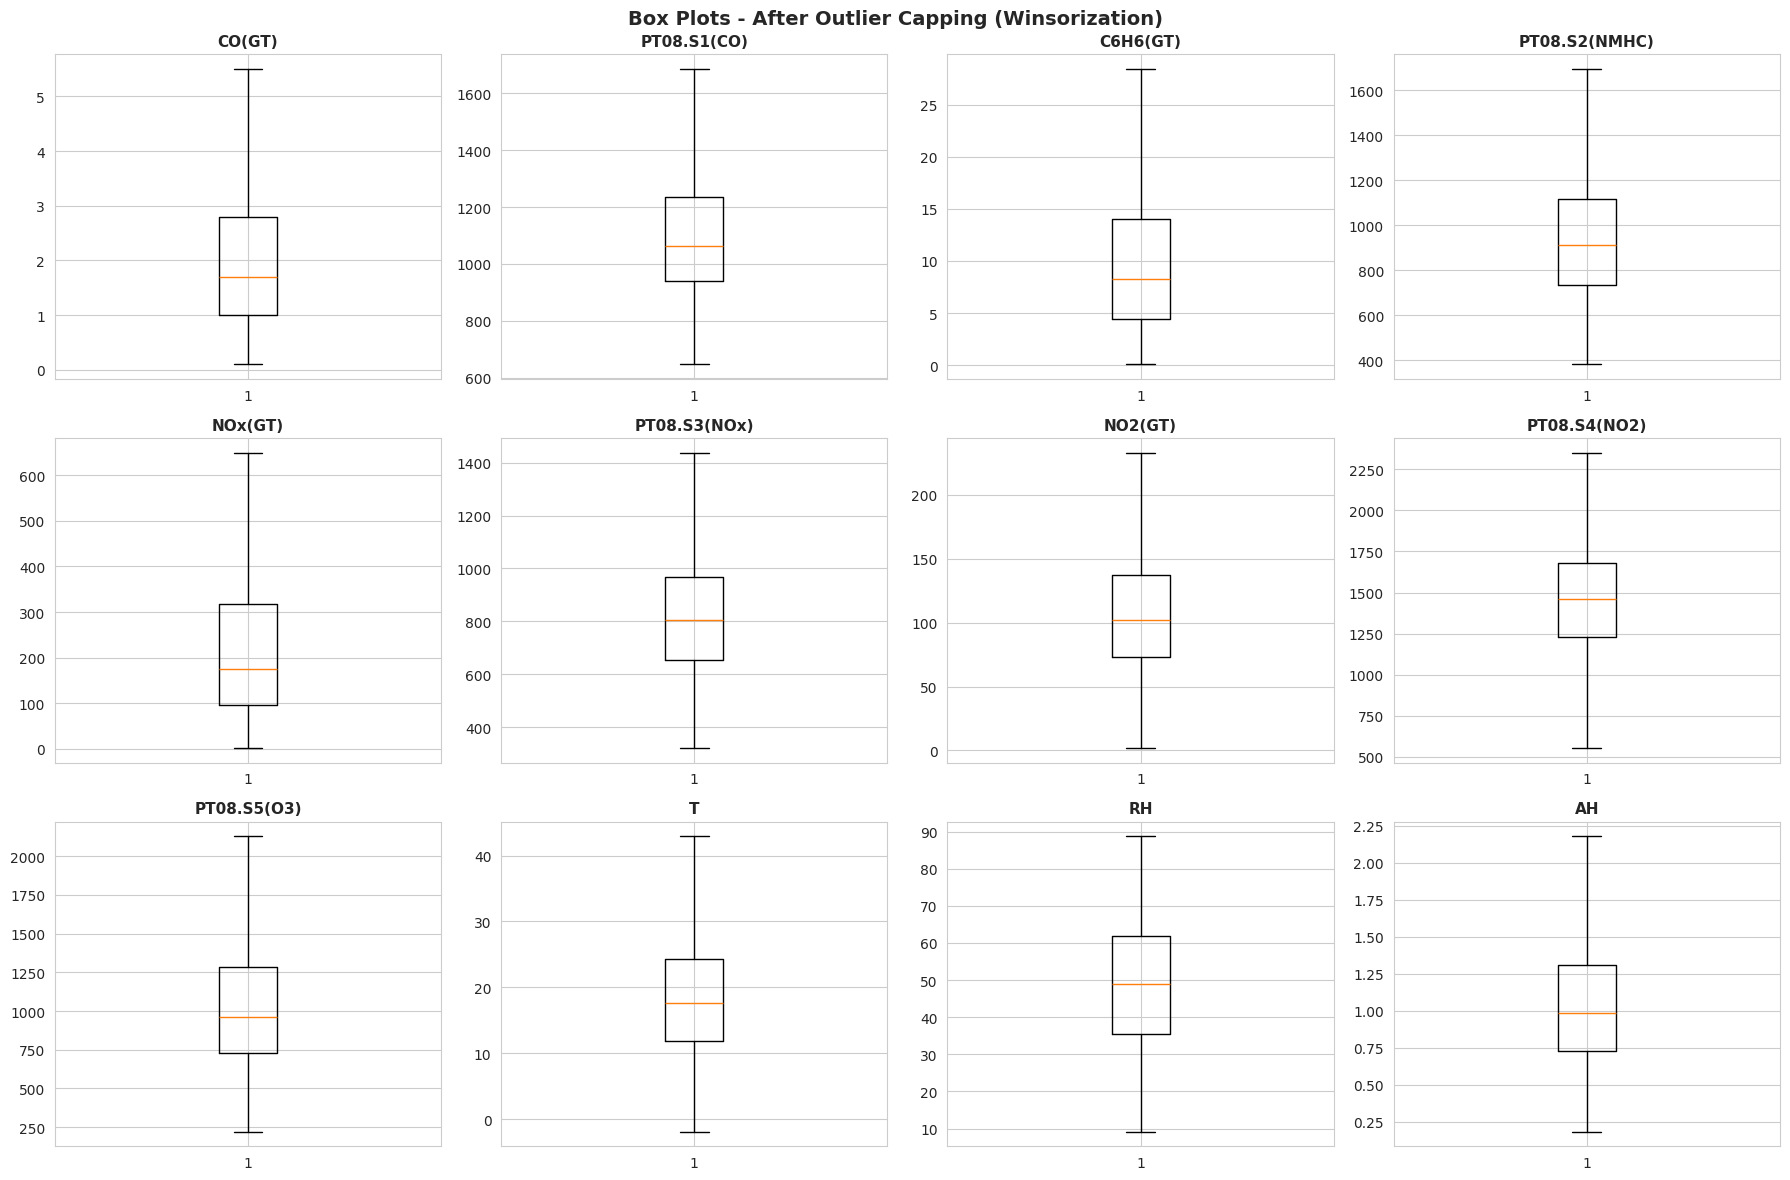

In [29]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    axes[i].boxplot(df_clean[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots - After Outlier Capping (Winsorization)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_after.png', dpi=150, bbox_inches='tight')
plt.show()

**2.3 Feature Scaling and Transformation**

In [30]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=df_clean.columns,
    index=df_clean.index
)


print(f"\nBefore scaling (sample means):")
for col in df_clean.columns[:5]:
    print(f"  {col}: mean={df_clean[col].mean():.2f}, std={df_clean[col].std():.2f}")

print(f"\nAfter scaling (all should be ~0 mean, ~1 std):")
for col in df_scaled.columns[:5]:
    print(f"  {col}: mean={df_scaled[col].mean():.4f}, std={df_scaled[col].std():.4f}")



Before scaling (sample means):
  CO(GT): mean=2.05, std=1.36
  PT08.S1(CO): mean=1101.59, std=216.10
  C6H6(GT): mean=10.04, std=7.07
  PT08.S2(NMHC): mean=941.81, std=267.23
  NOx(GT): mean=230.83, std=176.90

After scaling (all should be ~0 mean, ~1 std):
  CO(GT): mean=0.0000, std=1.0001
  PT08.S1(CO): mean=-0.0000, std=1.0001
  C6H6(GT): mean=-0.0000, std=1.0001
  PT08.S2(NMHC): mean=0.0000, std=1.0001
  NOx(GT): mean=0.0000, std=1.0001


All features now have mean ~0 and std ~1
No single feature will dominate the clustering

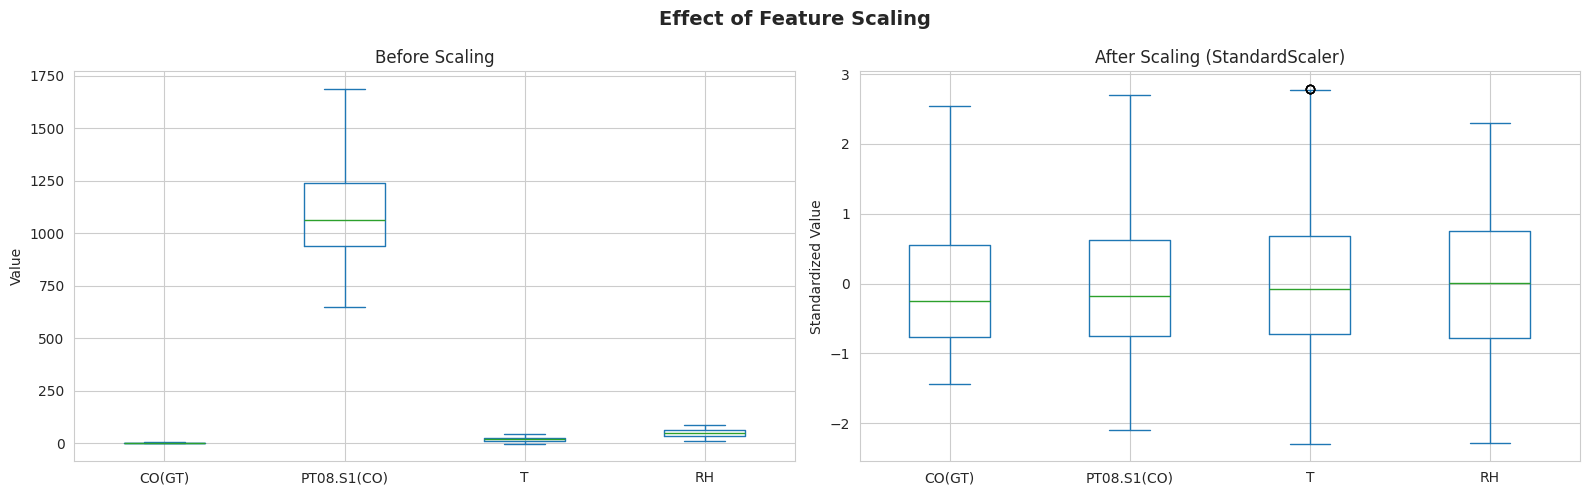

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before scaling
df_clean[['CO(GT)', 'PT08.S1(CO)', 'T', 'RH']].plot(kind='box', ax=axes[0])
axes[0].set_title('Before Scaling', fontsize=12)
axes[0].set_ylabel('Value')

# After scaling
df_scaled[['CO(GT)', 'PT08.S1(CO)', 'T', 'RH']].plot(kind='box', ax=axes[1])
axes[1].set_title('After Scaling (StandardScaler)', fontsize=12)
axes[1].set_ylabel('Standardized Value')

plt.suptitle('Effect of Feature Scaling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [32]:
df_scaled.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,
2004-03-10 18:00:00,0.406171,1.195859,0.263334,0.389918,-0.366522,0.964237,0.085218,0.700201,0.585236,-0.534786,0.004758,-0.641260
2004-03-10 19:00:00,-0.034974,0.881171,-0.090269,0.049364,-0.722676,1.461576,-0.370035,0.312805,-0.140862,-0.568799,-0.064393,-0.721055
2004-03-10 20:00:00,0.112074,1.390225,-0.146845,-0.010513,-0.564385,1.318275,0.106897,0.301154,0.109348,-0.727525,0.298649,-0.660036
2004-03-10 21:00:00,0.112074,1.269903,-0.118557,0.023168,-0.332603,1.115968,0.280327,0.385624,0.425789,-0.829563,0.644402,-0.569865
2004-03-10 22:00:00,-0.329071,0.788615,-0.500447,-0.395974,-0.564385,1.592233,0.150254,0.111826,0.197657,-0.806888,0.621352,-0.564677


Left: Features have very different scales (PT08.S1 dwarfs Temperature)

Right: After scaling, all features are on the same scale

**2.4 Clustering Model Development**

Deviding the data set into 2 periods

In [33]:
# Period 1: March 2004 - August 2004 (Spring/Summer)
period1_mask = (df_scaled.index >= '2004-03-01') & (df_scaled.index < '2004-09-01')
df_period1 = df_scaled[period1_mask]

# Period 2: September 2004 - March 2005 (Autumn/Winter)
period2_mask = (df_scaled.index >= '2004-09-01') & (df_scaled.index <= '2005-03-30')
df_period2 = df_scaled[period2_mask]

Compare mean values between periods

In [34]:
df_p1_orig = df_clean[period1_mask]
df_p2_orig = df_clean[period2_mask]

comparison = pd.DataFrame({
    'Period 1 Mean': df_p1_orig.mean(),
    'Period 2 Mean': df_p2_orig.mean(),
    'Change (%)': ((df_p2_orig.mean() - df_p1_orig.mean()) / df_p1_orig.mean() * 100)
}).round(2)
print(comparison.to_string())

               Period 1 Mean  Period 2 Mean  Change (%)
CO(GT)                  1.78           2.29       28.49
PT08.S1(CO)          1075.38        1126.30        4.74
C6H6(GT)                9.69          10.46        7.95
PT08.S2(NMHC)         934.00         953.52        2.09
NOx(GT)               116.55         326.67      180.29
PT08.S3(NOx)          899.06         767.28      -14.66
NO2(GT)                91.13         123.93       35.99
PT08.S4(NO2)         1618.91        1322.86      -18.29
PT08.S5(O3)           937.42        1113.42       18.78
T                      23.28          14.23      -38.87
RH                     42.71          54.09       26.65
AH                      1.15           0.92      -20.29


    Run elbow method and silhouette analysis to find optimal K.
    
    Returns the optimal K and the evaluation metrics.

- Inertia - How far are points from the center of their own cluster
- Silhouettes - are points close to their own cluster?/ are they far from other clusters? (higher the better)
- Davies - how similar clusters are to each other. (Lower is better)

model 1

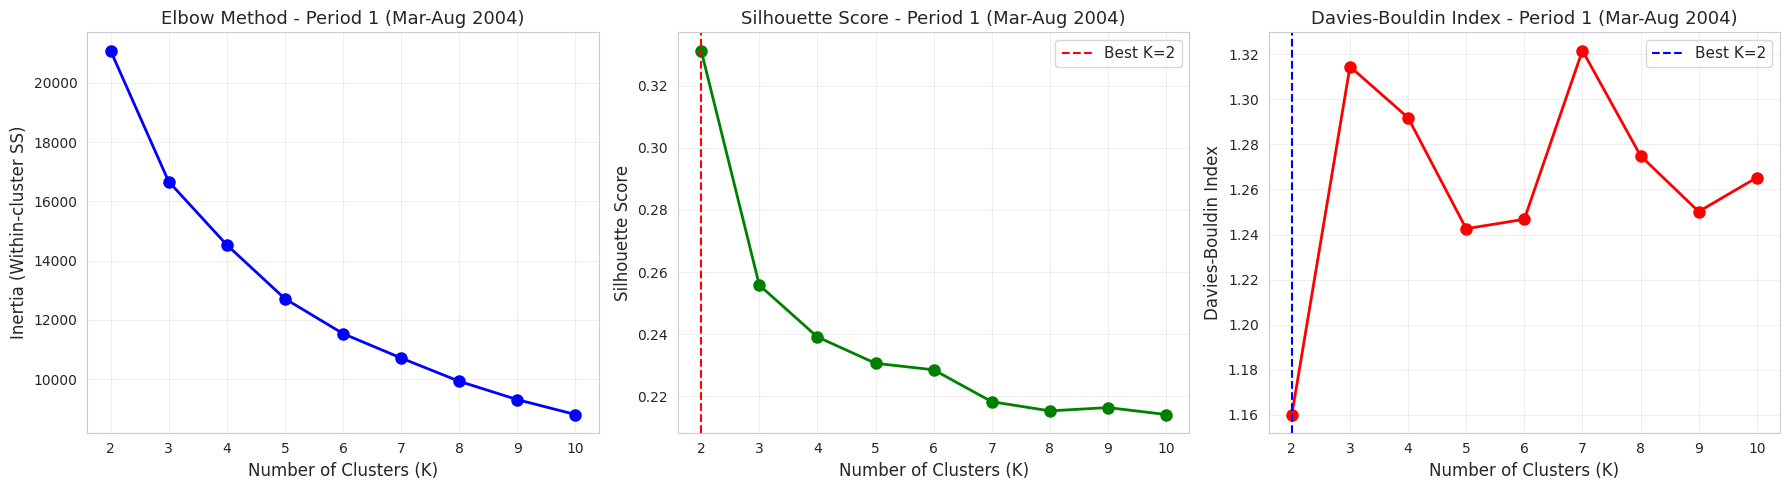


Period 1 (Mar-Aug 2004) - Evaluation Scores:
  K |      Inertia | Silhouette | Calinski-H |   Davies-B
------------------------------------------------------------
  2 |      21089.1 |     0.3313 |     2714.9 |     1.1602
  3 |      16670.3 |     0.2558 |     2270.7 |     1.3145
  4 |      14533.3 |     0.2391 |     1940.8 |     1.2918
  5 |      12718.7 |     0.2307 |     1811.8 |     1.2426
  6 |      11539.3 |     0.2286 |     1682.6 |     1.2468
  7 |      10715.1 |     0.2183 |     1563.2 |     1.3216
  8 |       9930.0 |     0.2154 |     1492.6 |     1.2749
  9 |       9311.4 |     0.2164 |     1427.1 |     1.2502
 10 |       8808.7 |     0.2142 |     1367.1 |     1.2652


In [35]:

K_range = range(2, 11)  # Try K from 2 to 10

def find_optimal_k(data, period_name):

    inertias = []       # Within-cluster sum of squares
    silhouettes = []    # Silhouette scores
    calinski = []       # Calinski-Harabasz scores
    davies = []         # Davies-Bouldin scores

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        labels = kmeans.fit_predict(data)

        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(data, labels))
        calinski.append(calinski_harabasz_score(data, labels))
        davies.append(davies_bouldin_score(data, labels))

    # Plot Elbow and Silhouette
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Elbow plot
    axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
    axes[0].set_ylabel('Inertia (Within-cluster SS)', fontsize=12)
    axes[0].set_title(f'Elbow Method - {period_name}', fontsize=13)
    axes[0].grid(True, alpha=0.3)

    # Silhouette plot
    axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
    axes[1].set_ylabel('Silhouette Score', fontsize=12)
    axes[1].set_title(f'Silhouette Score - {period_name}', fontsize=13)
    axes[1].grid(True, alpha=0.3)
    best_k_sil = list(K_range)[np.argmax(silhouettes)]
    axes[1].axvline(x=best_k_sil, color='red', linestyle='--',
                   label=f'Best K={best_k_sil}')
    axes[1].legend(fontsize=11)

    # Davies-Bouldin (lower is better)
    axes[2].plot(K_range, davies, 'ro-', linewidth=2, markersize=8)
    axes[2].set_xlabel('Number of Clusters (K)', fontsize=12)
    axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[2].set_title(f'Davies-Bouldin Index - {period_name}', fontsize=13)
    axes[2].grid(True, alpha=0.3)
    best_k_db = list(K_range)[np.argmin(davies)]
    axes[2].axvline(x=best_k_db, color='blue', linestyle='--',
                   label=f'Best K={best_k_db}')
    axes[2].legend(fontsize=11)

    plt.tight_layout()
    plt.savefig(f'optimal_k_{period_name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print scores
    print(f"\n{period_name} - Evaluation Scores:")
    print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>10} | {'Calinski-H':>10} | {'Davies-B':>10}")
    print("-" * 60)
    for i, k in enumerate(K_range):
        print(f"{k:>3} | {inertias[i]:>12.1f} | {silhouettes[i]:>10.4f} | {calinski[i]:>10.1f} | {davies[i]:>10.4f}")

    return best_k_sil, inertias, silhouettes

best_k1, _, _ = find_optimal_k(df_period1.values, 'Period 1 (Mar-Aug 2004)')

model 2

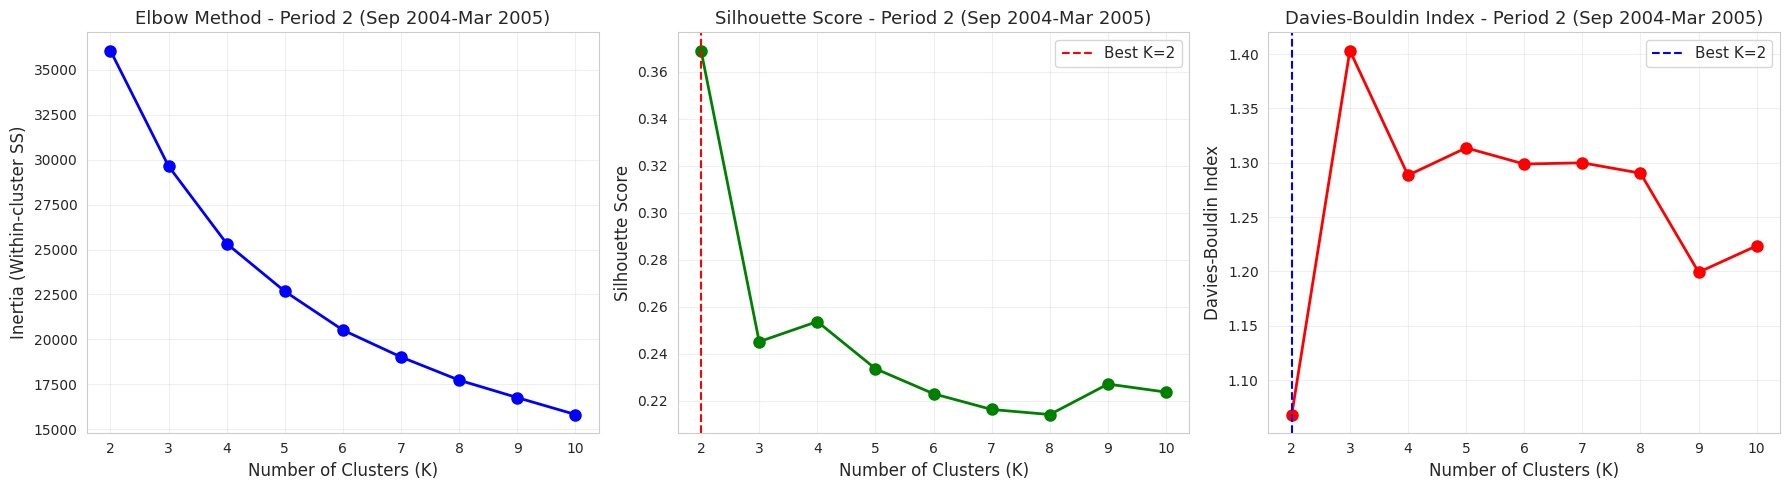


Period 2 (Sep 2004-Mar 2005) - Evaluation Scores:
  K |      Inertia | Silhouette | Calinski-H |   Davies-B
------------------------------------------------------------
  2 |      36083.7 |     0.3690 |     3936.6 |     1.0685
  3 |      29647.7 |     0.2452 |     2942.0 |     1.4032
  4 |      25336.3 |     0.2537 |     2580.3 |     1.2885
  5 |      22676.9 |     0.2337 |     2309.4 |     1.3137
  6 |      20519.2 |     0.2231 |     2147.3 |     1.2988
  7 |      19020.0 |     0.2164 |     1996.2 |     1.2999
  8 |      17730.0 |     0.2142 |     1887.5 |     1.2904
  9 |      16759.7 |     0.2272 |     1783.2 |     1.1993
 10 |      15817.3 |     0.2238 |     1712.5 |     1.2236


In [36]:
best_k2, _, _ = find_optimal_k(df_period2.values, 'Period 2 (Sep 2004-Mar 2005)')

Internal validation metrics favoured K = 2 for both periods.

In [37]:
# Use the same K for both periods (for fair comparison)
# Choose the K that works well for both
OPTIMAL_K = max(best_k1, best_k2)  # Use the higher of the two
# Alternatively, we can use K=4 which often works well for air quality data
# (representing: clean, moderate, polluted, very polluted air quality levels)
if OPTIMAL_K < 3:
    OPTIMAL_K = 4


print(f"CHOSEN K = {OPTIMAL_K} for both periods (for fair drift comparison)")


CHOSEN K = 4 for both periods (for fair drift comparison)


In [38]:
# Period 1 K-Means
kmeans_p1 = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=20,          # Run K-Means 20 times with different initial centroids
    max_iter=500        # Max iterations per run
)
labels_p1 = kmeans_p1.fit_predict(df_period1.values)

# Period 2 K-Means
kmeans_p2 = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=20,
    max_iter=500
)
labels_p2 = kmeans_p2.fit_predict(df_period2.values)


print(f"\nPeriod 1 - Cluster Sizes:")
for i in range(OPTIMAL_K):
    count = (labels_p1 == i).sum()
    print(f"  Cluster {i}: {count} records ({count/len(labels_p1)*100:.1f}%)")

print(f"\nPeriod 2 - Cluster Sizes:")
for i in range(OPTIMAL_K):
    count = (labels_p2 == i).sum()
    print(f"  Cluster {i}: {count} records ({count/len(labels_p2)*100:.1f}%)")


Period 1 - Cluster Sizes:
  Cluster 0: 835 records (20.0%)
  Cluster 1: 1328 records (31.8%)
  Cluster 2: 1254 records (30.0%)
  Cluster 3: 765 records (18.3%)

Period 2 - Cluster Sizes:
  Cluster 0: 1104 records (21.9%)
  Cluster 1: 1310 records (26.0%)
  Cluster 2: 1444 records (28.6%)
  Cluster 3: 1183 records (23.5%)


In [39]:
print(kmeans_p1.labels_[:10])

[0 0 0 0 0 2 2 2 2 2]


In [40]:
print(kmeans_p1.inertia_)

14533.25796555313


In [41]:
print(kmeans_p1.cluster_centers_.shape)

(4, 12)


In [42]:
print(type(kmeans_p1))

<class 'sklearn.cluster._kmeans.KMeans'>


**2.5 Cluster Evaluation**

Calculate and display all clustering evaluation metrics.

labels_p1 / labels_p2 has the cluster number (0-3)

In [43]:
def evaluate_clustering(data, labels, kmeans_model, period_name):

    sil = silhouette_score(data, labels)
    ch = calinski_harabasz_score(data, labels)
    db = davies_bouldin_score(data, labels)
    inertia = kmeans_model.inertia_

    print(f"\n{period_name}:")
    print(f"  Silhouette Score:     {sil:.4f}  (higher is better, max=1)")
    print(f"  Calinski-Harabasz:    {ch:.2f}  (higher is better)")
    print(f"  Davies-Bouldin:       {db:.4f}  (lower is better, min=0)")
    print(f"  Inertia:              {inertia:.2f}  (lower is better)")

    return {'Silhouette': sil, 'Calinski-Harabasz': ch, 'Davies-Bouldin': db, 'Inertia': inertia}


metrics_p1 = evaluate_clustering(df_period1.values, labels_p1, kmeans_p1, 'Period 1 (Mar-Aug 2004)')
metrics_p2 = evaluate_clustering(df_period2.values, labels_p2, kmeans_p2, 'Period 2 (Sep 2004-Mar 2005)')


Period 1 (Mar-Aug 2004):
  Silhouette Score:     0.2391  (higher is better, max=1)
  Calinski-Harabasz:    1940.79  (higher is better)
  Davies-Bouldin:       1.2918  (lower is better, min=0)
  Inertia:              14533.26  (lower is better)

Period 2 (Sep 2004-Mar 2005):
  Silhouette Score:     0.2537  (higher is better, max=1)
  Calinski-Harabasz:    2580.30  (higher is better)
  Davies-Bouldin:       1.2885  (lower is better, min=0)
  Inertia:              25336.34  (lower is better)


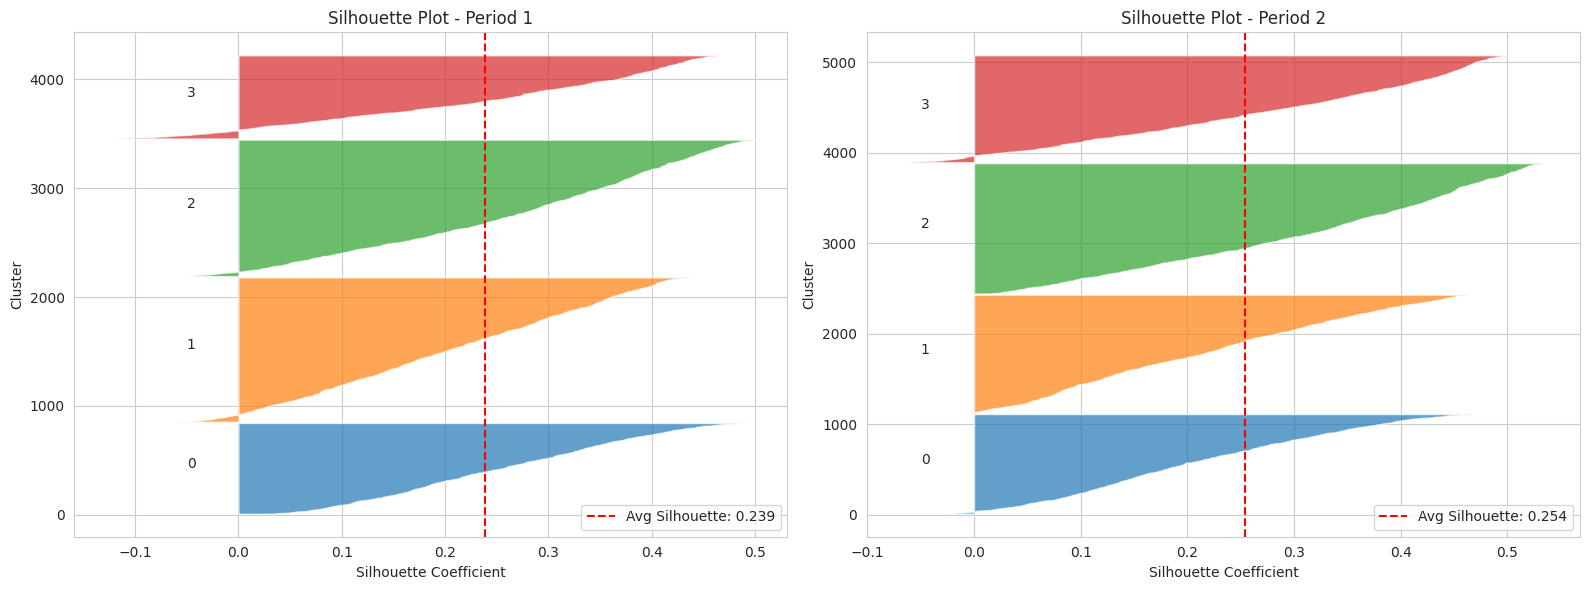

In [44]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, labels, title in [(axes[0], df_period1.values, labels_p1, 'Period 1'),
                                  (axes[1], df_period2.values, labels_p2, 'Period 2')]:
    sample_silhouette_values = silhouette_samples(data, labels)
    avg_score = silhouette_score(data, labels)

    y_lower = 10
    for i in range(OPTIMAL_K):
        cluster_silhouette_vals = sample_silhouette_values[labels == i]
        cluster_silhouette_vals.sort()

        y_upper = y_lower + len(cluster_silhouette_vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                        alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(cluster_silhouette_vals), str(i))
        y_lower = y_upper + 10

    ax.axvline(x=avg_score, color='red', linestyle='--',
              label=f'Avg Silhouette: {avg_score:.3f}')
    ax.set_title(f'Silhouette Plot - {title}', fontsize=12)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('silhouette_plots.png', dpi=150, bbox_inches='tight')
plt.show()

CLUSTER PROFILES - Period 1 (Mar-Aug 2004) (Original Scale)
         CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)      T     RH    AH
Cluster                                                                                                                             
0          2.05      1147.40      9.66         958.85   133.86        890.88    97.95       1605.70      1014.10  16.98  50.06  0.94
1          1.51      1040.11      9.48         949.80    99.37        812.82    91.87       1633.61       873.28  30.91  32.26  1.35
2          0.87       886.58      3.54         676.09    55.94       1142.73    59.41       1383.24       632.88  19.26  50.19  1.10
3          3.45      1367.46     20.14        1302.24   226.80        658.26   134.39       1994.15      1464.24  23.51  40.57  1.10


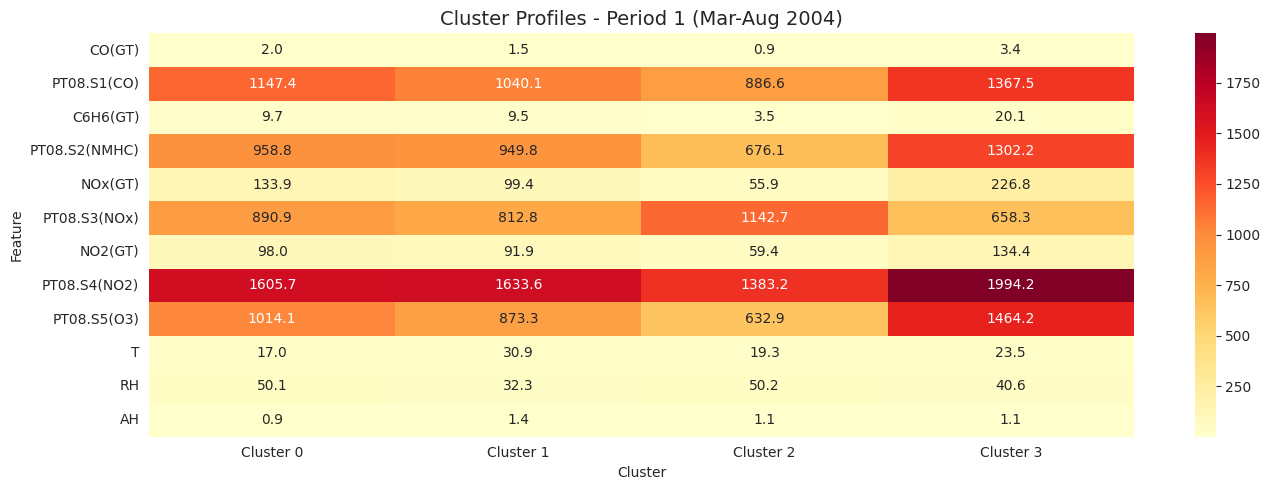

CLUSTER PROFILES - Period 2 (Sep 2004-Mar 2005) (Original Scale)
         CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)      T     RH    AH
Cluster                                                                                                                             
0          2.45      1144.64     10.00         968.28   393.63        691.64   164.47       1167.57      1239.72   9.83  50.06  0.59
1          1.88      1081.02      8.74         915.40   264.67        756.83    95.12       1440.64       994.67  20.10  57.64  1.29
2          0.99       895.33      3.17         650.05   155.98       1045.18    91.61        974.76       667.92   9.69  52.17  0.65
3          4.17      1441.25     21.68        1352.37   541.18        510.22   157.44       1762.27      1670.85  17.39  56.25  1.13


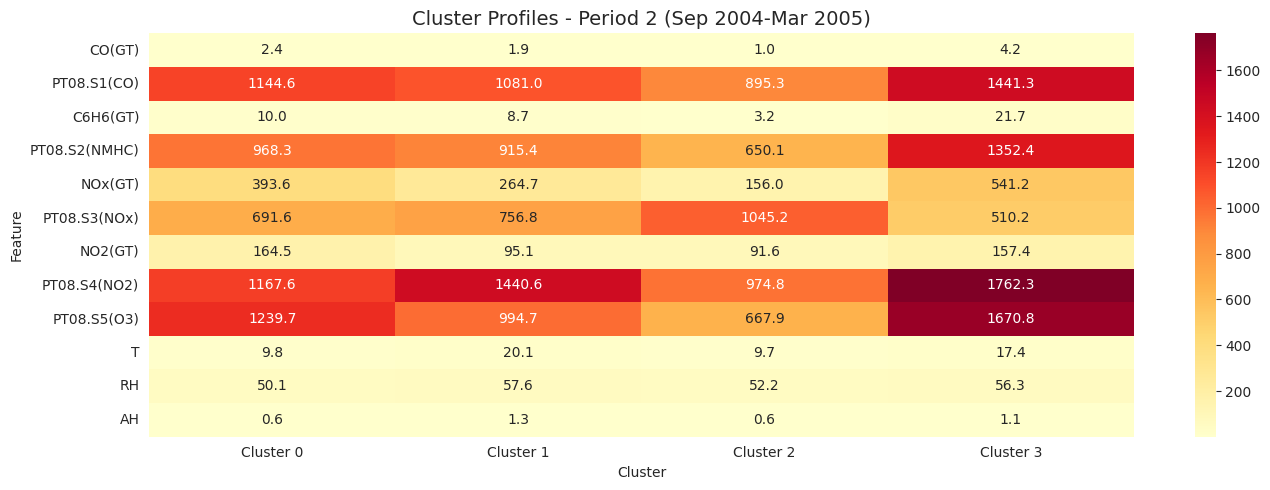

In [45]:
def cluster_profiles(df_orig, labels, period_name):
    """Show the mean feature values for each cluster (in original scale)."""
    df_with_labels = df_orig.copy()
    df_with_labels['Cluster'] = labels

    profiles = df_with_labels.groupby('Cluster').mean()

    print(f"CLUSTER PROFILES - {period_name} (Original Scale)")
    print(f"{'='*80}")
    print(profiles.round(2).to_string())

    # Heatmap of cluster profiles
    plt.figure(figsize=(14, 5))
    sns.heatmap(profiles.T, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=[f'Cluster {i}' for i in range(OPTIMAL_K)])
    plt.title(f'Cluster Profiles - {period_name}', fontsize=14)
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(f'cluster_profiles_{period_name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return profiles

profiles_p1 = cluster_profiles(df_p1_orig, labels_p1, 'Period 1 (Mar-Aug 2004)')
profiles_p2 = cluster_profiles(df_p2_orig, labels_p2, 'Period 2 (Sep 2004-Mar 2005)')

**2.6 Model Drift Analysis**

Model drift occurs when the statistical properties of the data change over time. In this case, it means air quality patterns in Period 2 are different from Period 1.

Drift Analaysis 1: Centroid Shifts

-> Euclidean distance between corresponding centroids in standardized space.

In [46]:
centroids_p1 = kmeans_p1.cluster_centers_
centroids_p2 = kmeans_p2.cluster_centers_

print("CENTROID SHIFT ANALYSIS")
print("=" * 60)

# Match clusters between periods using nearest centroid matching
# (Cluster 0 in Period 1 might correspond to Cluster 2 in Period 2)
from scipy.spatial.distance import cdist

# Calculate distance matrix between all centroids
dist_matrix = cdist(centroids_p1, centroids_p2, metric='euclidean')

print(f"\nDistance Matrix (Period 1 centroids vs Period 2 centroids):")
dist_df = pd.DataFrame(dist_matrix,
                       index=[f'P1_Cluster_{i}' for i in range(OPTIMAL_K)],
                       columns=[f'P2_Cluster_{i}' for i in range(OPTIMAL_K)])
print(dist_df.round(3).to_string())

# Find best matching (best overoll pairing)
from scipy.optimize import linear_sum_assignment
row_ind, col_ind = linear_sum_assignment(dist_matrix)

print(f"\nBest Cluster Matching (Period 1 → Period 2):")
total_shift = 0
for r, c in zip(row_ind, col_ind):
    shift = dist_matrix[r, c]
    total_shift += shift
    print(f"  P1 Cluster {r} → P2 Cluster {c}: shift = {shift:.4f}")

print(f"\nAverage Centroid Shift: {total_shift/OPTIMAL_K:.4f}")
print(f"Total Centroid Shift: {total_shift:.4f}")

CENTROID SHIFT ANALYSIS

Distance Matrix (Period 1 centroids vs Period 2 centroids):
              P2_Cluster_0  P2_Cluster_1  P2_Cluster_2  P2_Cluster_3
P1_Cluster_0         2.892         1.528         3.148         4.693
P1_Cluster_1         4.378         2.267         4.214         5.563
P1_Cluster_2         4.755         2.927         2.208         7.245
P1_Cluster_3         4.115         3.741         6.340         2.509

Best Cluster Matching (Period 1 → Period 2):
  P1 Cluster 0 → P2 Cluster 0: shift = 2.8921
  P1 Cluster 1 → P2 Cluster 1: shift = 2.2665
  P1 Cluster 2 → P2 Cluster 2: shift = 2.2080
  P1 Cluster 3 → P2 Cluster 3: shift = 2.5086

Average Centroid Shift: 2.4688
Total Centroid Shift: 9.8752


Drift Analaysis 2: Cluster Membership Change

CLUSTER MEMBERSHIP CHANGES

   Cluster | Period 1 % | Period 2 % |     Change
--------------------------------------------------
 Cluster 0 |      20.0% |      21.9% | +1.9%
 Cluster 1 |      31.8% |      26.0% | -5.8%
 Cluster 2 |      30.0% |      28.6% | -1.3%
 Cluster 3 |      18.3% |      23.5% | +5.2%


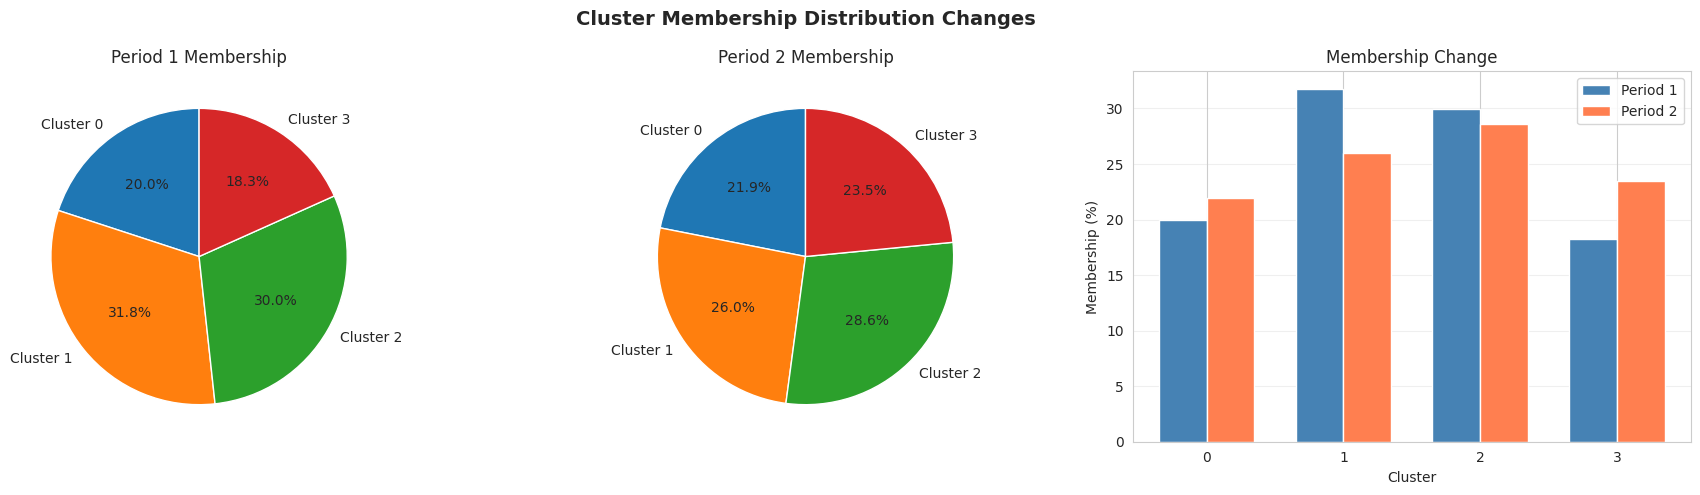

In [47]:
# Calculate cluster membership proportions
membership_p1 = np.bincount(labels_p1, minlength=OPTIMAL_K) / len(labels_p1)
membership_p2 = np.bincount(labels_p2, minlength=OPTIMAL_K) / len(labels_p2)


print("CLUSTER MEMBERSHIP CHANGES")
print("=" * 60)
print(f"\n{'Cluster':>10} | {'Period 1 %':>10} | {'Period 2 %':>10} | {'Change':>10}")
print("-" * 50)
for i in range(OPTIMAL_K):
    change = membership_p2[i] - membership_p1[i]
    direction = '+' if change > 0 else ''
    print(f"{'Cluster '+str(i):>10} | {membership_p1[i]*100:>9.1f}% | {membership_p2[i]*100:>9.1f}% | {direction}{change*100:.1f}%")

# Visualize membership changes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie charts
axes[0].pie(membership_p1, labels=[f'Cluster {i}' for i in range(OPTIMAL_K)],
           autopct='%1.1f%%', startangle=90)
axes[0].set_title('Period 1 Membership', fontsize=12)

axes[1].pie(membership_p2, labels=[f'Cluster {i}' for i in range(OPTIMAL_K)],
           autopct='%1.1f%%', startangle=90)
axes[1].set_title('Period 2 Membership', fontsize=12)

# Side-by-side bar chart
x = np.arange(OPTIMAL_K)
width = 0.35
axes[2].bar(x - width/2, membership_p1 * 100, width, label='Period 1', color='steelblue')
axes[2].bar(x + width/2, membership_p2 * 100, width, label='Period 2', color='coral')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Membership (%)')
axes[2].set_title('Membership Change', fontsize=12)
axes[2].set_xticks(x)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Cluster Membership Distribution Changes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('membership_changes.png', dpi=150, bbox_inches='tight')
plt.show()

Quantify Drift: KL Divergence

KL Divergence measures how different two probability distributions are. We compare:
 1. Overall cluster membership distributions (which clusters are popular?)
 2. Feature distributions per cluster (did the cluster characteristics change?)

In [48]:
print("KL DIVERGENCE ON CLUSTER MEMBERSHIP")
print("=" * 60)

# STEP 1: Turn cluster counts into probability distributions.
# (Small epsilon prevents log(0) errors if any cluster is empty.)
epsilon = 1e-10
P1 = (membership_p1 + epsilon) / (membership_p1 + epsilon).sum()
P2 = (membership_p2 + epsilon) / (membership_p2 + epsilon).sum()

# STEP 2: Compute KL Divergence between the two periods.
kl_drift = entropy(P1, P2)   # scipy's entropy(P, Q) = KL(P || Q)

print(f"\n   KL Divergence (Period 1 → Period 2): {kl_drift:.4f}")

# Simple interpretation
if kl_drift < 0.01:
    level = "NEGLIGIBLE"
elif kl_drift < 0.05:
    level = "MILD"
elif kl_drift < 0.1:
    level = "MODERATE"
else:
    level = "SIGNIFICANT"

print(f"   >>> Drift Level: {level}")
print(f"   >>> (0 = identical cluster usage, higher = bigger shift)")

KL DIVERGENCE ON CLUSTER MEMBERSHIP

   KL Divergence (Period 1 → Period 2): 0.0133
   >>> Drift Level: MILD
   >>> (0 = identical cluster usage, higher = bigger shift)


In [49]:
print("\n2. FEATURE-LEVEL KL DIVERGENCE (which features drifted most?):")
print(f"   {'Feature':>20s} | {'KL Divergence':>14} | {'Drift Level'}")
print("   " + "-" * 55)

feature_drifts = []
for col in df_clean.columns:
    # STEP 1: Build histograms (probability distributions) for each period.
    bins = np.linspace(df_clean[col].min(), df_clean[col].max(), 50)
    hist_p1, _ = np.histogram(df_p1_orig[col], bins=bins, density=True)
    hist_p2, _ = np.histogram(df_p2_orig[col], bins=bins, density=True)

    # STEP 2: Add epsilon and normalize to valid probability distributions.
    hist_p1 = (hist_p1 + epsilon) / (hist_p1 + epsilon).sum()
    hist_p2 = (hist_p2 + epsilon) / (hist_p2 + epsilon).sum()

    # STEP 3: Compute KL Divergence.
    kl = entropy(hist_p1, hist_p2)

    level = "LOW" if kl < 0.05 else ("MEDIUM" if kl < 0.15 else "HIGH")
    feature_drifts.append({'Feature': col, 'KL': kl, 'Level': level})

    print(f"   {col:>20s} | {kl:>14.4f} | {level}")

# Sort by KL to find most drifted features
feature_drifts_df = pd.DataFrame(feature_drifts).sort_values('KL', ascending=False)

print(f"\n   >>> Most drifted feature: {feature_drifts_df.iloc[0]['Feature']} (KL={feature_drifts_df.iloc[0]['KL']:.4f})")
print(f"   >>> Least drifted feature: {feature_drifts_df.iloc[-1]['Feature']} (KL={feature_drifts_df.iloc[-1]['KL']:.4f})")


2. FEATURE-LEVEL KL DIVERGENCE (which features drifted most?):
                Feature |  KL Divergence | Drift Level
   -------------------------------------------------------
                 CO(GT) |         0.1587 | HIGH
            PT08.S1(CO) |         0.0731 | MEDIUM
               C6H6(GT) |         0.0653 | MEDIUM
          PT08.S2(NMHC) |         0.0675 | MEDIUM
                NOx(GT) |         1.0590 | HIGH
           PT08.S3(NOx) |         0.2591 | HIGH
                NO2(GT) |         0.3453 | HIGH
           PT08.S4(NO2) |         0.5686 | HIGH
            PT08.S5(O3) |         0.1351 | MEDIUM
                      T |         0.8197 | HIGH
                     RH |         0.3953 | HIGH
                     AH |         0.5187 | HIGH

   >>> Most drifted feature: NOx(GT) (KL=1.0590)
   >>> Least drifted feature: C6H6(GT) (KL=0.0653)


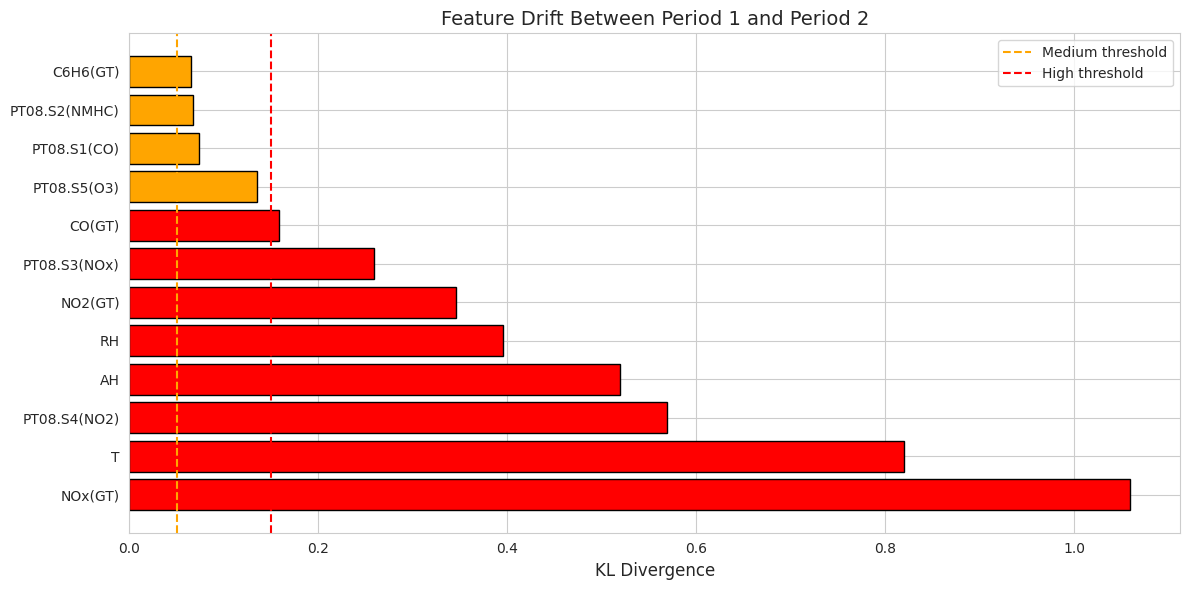

In [50]:

plt.figure(figsize=(12, 6))
colors_drift = ['red' if l == 'HIGH' else ('orange' if l == 'MEDIUM' else 'green')
                for l in feature_drifts_df['Level']]
plt.barh(feature_drifts_df['Feature'], feature_drifts_df['KL'], color=colors_drift, edgecolor='black')
plt.xlabel('KL Divergence', fontsize=12)
plt.title('Feature Drift Between Period 1 and Period 2', fontsize=14)
plt.axvline(x=0.05, color='orange', linestyle='--', label='Medium threshold')
plt.axvline(x=0.15, color='red', linestyle='--', label='High threshold')
plt.legend()
plt.tight_layout()
plt.savefig('feature_drift.png', dpi=150, bbox_inches='tight')
plt.show()

The same broad cluster structure remained, but the actual environmental and pollution conditions inside the data changed noticeably between periods.

**2.7 Visualization - PCA**

In [51]:
# Fit PCA on the entire dataset (both periods)
pca = PCA(n_components=2)
pca.fit(df_scaled.values)

# Transform both periods
pca_p1 = pca.transform(df_period1.values)
pca_p2 = pca.transform(df_period2.values)

# Also transform centroids for visualization
centroids_p1_pca = pca.transform(centroids_p1)
centroids_p2_pca = pca.transform(centroids_p2)

print(f"PCA Explained Variance:")
print(f"  PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of total variance")
print(f"  PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of total variance")
print(f"  Together: {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance")

# Show which features contribute most to each component
print(f"\nFeature contributions to PC1 (top 5):")
pc1_loadings = pd.Series(abs(pca.components_[0]), index=df_scaled.columns).sort_values(ascending=False)
for feat, val in pc1_loadings.head(5).items():
    print(f"  {feat}: {val:.3f}")

print(f"\nFeature contributions to PC2 (top 5):")
pc2_loadings = pd.Series(abs(pca.components_[1]), index=df_scaled.columns).sort_values(ascending=False)
for feat, val in pc2_loadings.head(5).items():
    print(f"  {feat}: {val:.3f}")

PCA Explained Variance:
  PC1 explains 55.7% of total variance
  PC2 explains 20.7% of total variance
  Together: 76.5% of total variance

Feature contributions to PC1 (top 5):
  PT08.S2(NMHC): 0.371
  C6H6(GT): 0.367
  PT08.S1(CO): 0.362
  PT08.S5(O3): 0.360
  PT08.S3(NOx): 0.341

Feature contributions to PC2 (top 5):
  T: 0.569
  AH: 0.514
  PT08.S4(NO2): 0.407
  NO2(GT): 0.308
  NOx(GT): 0.290


PC1 -> Likely general air-pollution / sensor-response axis  
PC2 -> Likelt seasonal / environmental conditions axis

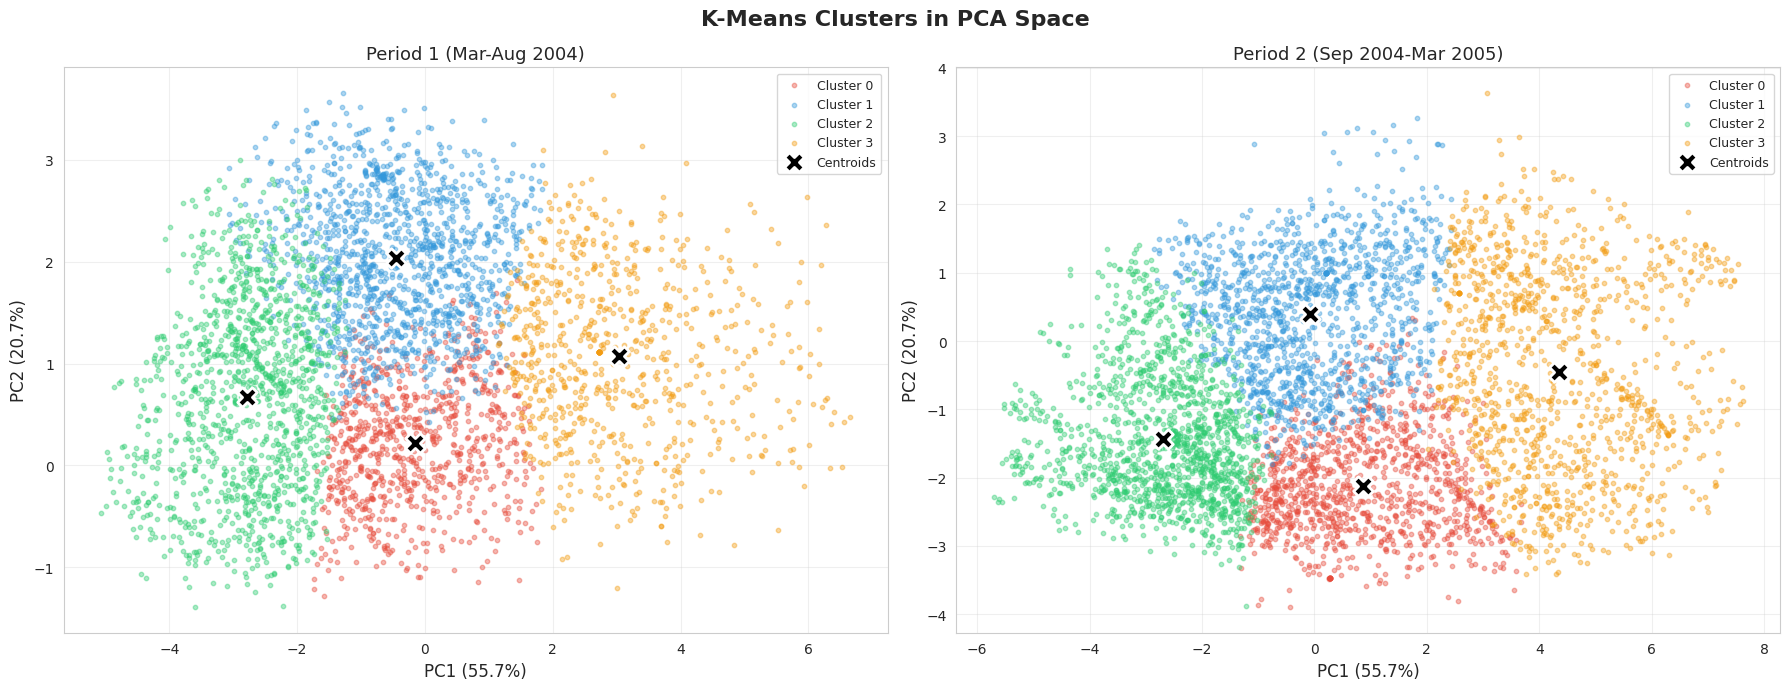

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax, pca_data, labels, centroids_pca, title in [
    (axes[0], pca_p1, labels_p1, centroids_p1_pca, 'Period 1 (Mar-Aug 2004)'),
    (axes[1], pca_p2, labels_p2, centroids_p2_pca, 'Period 2 (Sep 2004-Mar 2005)')
]:
    for i in range(OPTIMAL_K):
        mask = labels == i
        ax.scatter(pca_data[mask, 0], pca_data[mask, 1],
                  c=colors[i], label=f'Cluster {i}', alpha=0.4, s=10)

    # Plot centroids as large markers
    ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
              c='black', marker='X', s=200, linewidths=2,
              edgecolors='white', zorder=5, label='Centroids')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('K-Means Clusters in PCA Space', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


> Each dot is one hourly reading. Colors represent different clusters.   
> Black X marks show cluster centroids (the center of each group).   
> Two plots shows how clusters shifted between periods.

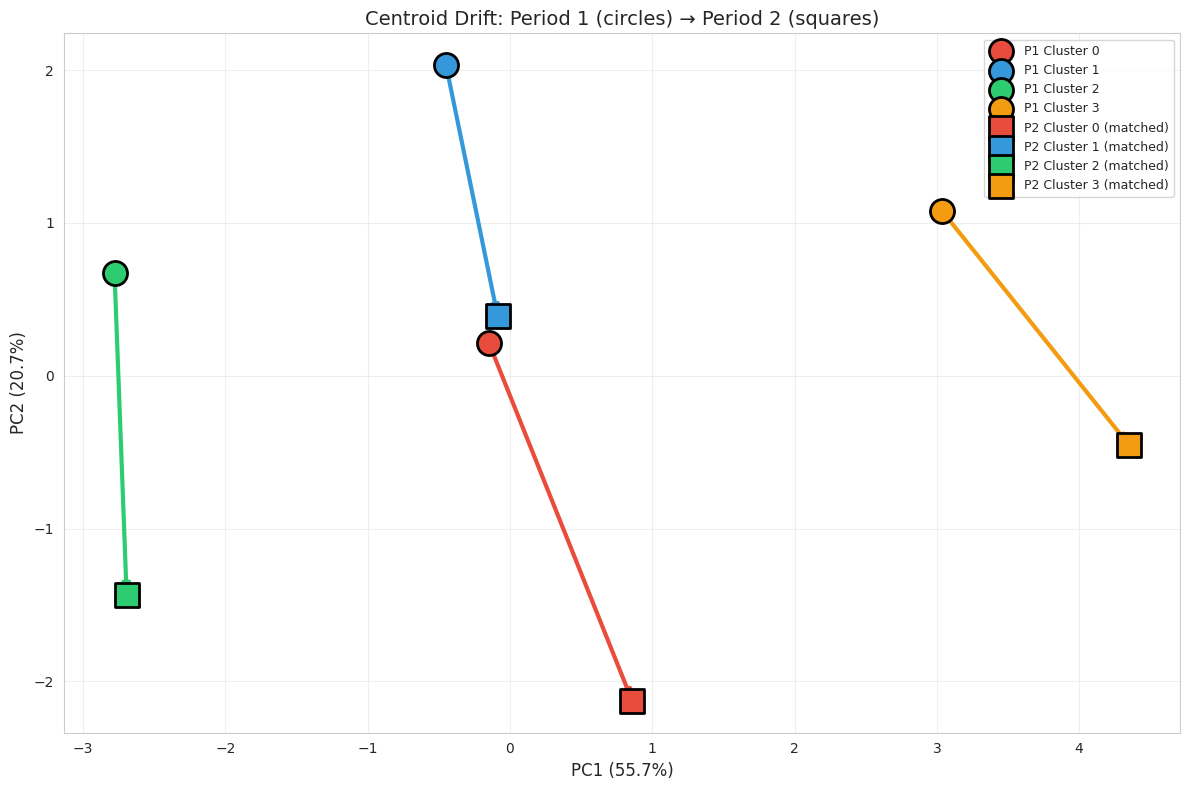

In [56]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Period 1 centroids
for i in range(OPTIMAL_K):
    ax.scatter(centroids_p1_pca[i, 0], centroids_p1_pca[i, 1],
              c=colors[i], marker='o', s=300, edgecolors='black', linewidths=2,
              label=f'P1 Cluster {i}', zorder=5)

# Plot Period 2 centroids (matched)
for i in range(OPTIMAL_K):
    matched_j = col_ind[i]  # Matched cluster in Period 2
    ax.scatter(centroids_p2_pca[matched_j, 0], centroids_p2_pca[matched_j, 1],
              c=colors[i], marker='s', s=300, edgecolors='black', linewidths=2,
              label=f'P2 Cluster {matched_j} (matched)', zorder=5)

    # Draw arrow showing the drift direction
    ax.annotate('', xy=(centroids_p2_pca[matched_j, 0], centroids_p2_pca[matched_j, 1]),
               xytext=(centroids_p1_pca[i, 0], centroids_p1_pca[i, 1]),
               arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Centroid Drift: Period 1 (circles) → Period 2 (squares)', fontsize=14)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('centroid_drift.png', dpi=150, bbox_inches='tight')
plt.show()

Arrows show how cluster centers moved from Period 1 to Period 2.   
Longer arrows = more drift (bigger change in air quality patterns).

**2.8 Conclusion and Insights**

In [55]:

print(" Conclusion")
print("=" * 70)

print(f"\nDataset: Air Quality UCI (9,357 hourly recordings, Italy 2004-2005)")
print(f"Features used: {len(df_clean.columns)} (after dropping NMHC(GT))")
print(f"Optimal K: {OPTIMAL_K} clusters")

print(f"\nClustering Performance:")
print(f"  {'Metric':<25s} | {'Period 1':>10} | {'Period 2':>10}")
print(f"  {'-'*50}")
for metric in ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']:
    print(f"  {metric:<25s} | {metrics_p1[metric]:>10.4f} | {metrics_p2[metric]:>10.4f}")

print(f"\nDrift Analysis:")
print(f"  KL Divergence: {kl_drift:.6f} ({level} drift)")
print(f"  Average Centroid Shift: {total_shift/OPTIMAL_K:.4f}")
print(f"  Most drifted feature: {feature_drifts_df.iloc[0]['Feature']}")


 Conclusion

Dataset: Air Quality UCI (9,357 hourly recordings, Italy 2004-2005)
Features used: 12 (after dropping NMHC(GT))
Optimal K: 4 clusters

Clustering Performance:
  Metric                    |   Period 1 |   Period 2
  --------------------------------------------------
  Silhouette                |     0.2391 |     0.2537
  Calinski-Harabasz         |  1940.7926 |  2580.3049
  Davies-Bouldin            |     1.2918 |     1.2885

Drift Analysis:
  KL Divergence: 0.013342 (HIGH drift)
  Average Centroid Shift: 2.4688
  Most drifted feature: NOx(GT)
